# 🔵 TẦNG 3 — PREDICTIVE ANALYTICS
## *"What will happen?"* — Điều gì sẽ xảy ra?

> **Mục tiêu:** Xây dựng & so sánh các mô hình Machine Learning để dự đoán lương.  
> **Trả lời:**  
> - ❓ Câu hỏi 4: Yếu tố nào ảnh hưởng mạnh nhất đến lương?

---

## ⚙️ PHẦN 0: IMPORT & CHUẨN BỊ DỮ LIỆU

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap

plt.rcParams.update({
    'figure.figsize'   : (13, 6),
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')
PALETTE = sns.color_palette('husl', 12)
BLUE  = '#2563EB'
RED   = '#EF4444'
GREEN = '#10B981'

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


In [2]:
# ─────────────────────────────────────────────────────────────
# ĐỌC & LÀM SẠCH DỮ LIỆU
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

df = pd.read_csv('salary_data.csv')

# chuẩn hoá tên cột
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)

# xoá duplicate
df = df.drop_duplicates()

# ─────────────────────────────────────
# Tìm cột salary
# ─────────────────────────────────────
sal_kw = [
    'salary',
    'pay',
    'comp',
    'wage',
    'income',
    'ctc',
    'annual'
]

SAL_COL = next(
    (c for c in df.columns if any(k in c for k in sal_kw)),
    'salary'
)

print(f'📌 Salary column: {SAL_COL}')

# ─────────────────────────────────────
# Làm sạch salary
# ─────────────────────────────────────

# ép toàn bộ về string
df[SAL_COL] = df[SAL_COL].astype(str)

# lowercase
df[SAL_COL] = df[SAL_COL].str.lower()

# xử lý 120k -> 120000
df[SAL_COL] = df[SAL_COL].str.replace(
    r'(\d+(?:\.\d+)?)k',
    lambda m: str(float(m.group(1)) * 1000),
    regex=True
)

# bỏ ký tự đặc biệt
df[SAL_COL] = (
    df[SAL_COL]
    .str.replace(',', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace(r'[^0-9.]', '', regex=True)
    .str.strip()
)

# convert numeric an toàn
df[SAL_COL] = pd.to_numeric(
    df[SAL_COL],
    errors='coerce'
)

# xoá NaN
df = df.dropna(subset=[SAL_COL])

# ép float thật sự
df[SAL_COL] = df[SAL_COL].astype(float)

# kiểm tra kiểu dữ liệu
print('\n📌 Data type:')
print(df[SAL_COL].dtype)

print('\n📌 Actual python types:')
print(df[SAL_COL].apply(type).value_counts())

# ─────────────────────────────────────
# Loại outlier
# ─────────────────────────────────────
q01 = df[SAL_COL].quantile(0.01)
q99 = df[SAL_COL].quantile(0.99)

df = df[
    (df[SAL_COL] >= q01) &
    (df[SAL_COL] <= q99)
]

# ─────────────────────────────────────
# Fill missing values
# ─────────────────────────────────────
for col in df.columns:

    if df[col].isnull().sum() > 0:

        if pd.api.types.is_numeric_dtype(df[col]):

            df[col] = df[col].fillna(
                df[col].median()
            )

        else:

            df[col] = df[col].fillna(
                df[col].mode()[0]
            )

# salary cuối cùng
sal = df[SAL_COL]

# ─────────────────────────────────────
# Kết quả
# ─────────────────────────────────────
print('\n' + '='*60)

print(
    f'✅ Dữ liệu sẵn sàng: {df.shape[0]:,} dòng'
)

print(
    f'✅ Cột lương: "{SAL_COL}"'
)

print(
    f'✅ Salary range: ${sal.min():,.0f} → ${sal.max():,.0f}'
)

print('='*60)

📌 Salary column: company_name

📌 Data type:
float64

📌 Actual python types:
company_name
<class 'float'>    412
Name: count, dtype: int64

✅ Dữ liệu sẵn sàng: 406 dòng
✅ Cột lương: "company_name"
✅ Salary range: $1 → $17,544


---
## 📌 PHẦN 1: CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH

In [3]:
df_model = df.copy()

# ── Mã hóa biến phân loại (Label Encoding) ──────────────────
cat_cols = df_model.select_dtypes(include=['object','category']).columns.tolist()
print(f'Mã hóa {len(cat_cols)} cột phân loại: {cat_cols}')

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col]  = le

print('✅ Mã hóa hoàn tất')

# ── Tách X và y ──────────────────────────────────────────────
X = df_model.drop(columns=[SAL_COL])
y = df_model[SAL_COL]
FEATURE_NAMES = X.columns.tolist()

print(f'\n📌 Features (X): {X.shape[1]} cột → {FEATURE_NAMES}')
print(f'📌 Target  (y): {len(y):,} mẫu')
print(f'   Khoảng lương: ${y.min():,.0f} – ${y.max():,.0f}')

Mã hóa 4 cột phân loại: ['job_title', 'location', 'employment_status', 'job_roles']
✅ Mã hóa hoàn tất

📌 Features (X): 7 cột → ['rating', 'job_title', 'salary', 'salaries_reported', 'location', 'employment_status', 'job_roles']
📌 Target  (y): 406 mẫu
   Khoảng lương: $1 – $17,544


In [4]:
# ── Train / Test Split 80/20 ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale cho Linear Models
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Chia dữ liệu Train/Test:')
print(f'   Train : {len(X_train):,} mẫu ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Test  : {len(X_test):,}  mẫu ({len(X_test)/len(X)*100:.0f}%)')

✅ Chia dữ liệu Train/Test:
   Train : 324 mẫu (80%)
   Test  : 82  mẫu (20%)


---
## 📌 PHẦN 2: HUẤN LUYỆN 7 MÔ HÌNH

In [5]:
# ── Hàm đánh giá mô hình ────────────────────────────────────
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    mae    = mean_absolute_error(y_te, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    r2     = r2_score(y_te, y_pred)
    mape   = np.mean(np.abs((y_te - y_pred) / (np.abs(y_te) + 1e-8))) * 100
    cv_r2  = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f'  [{name:<22}]  R²={r2:.4f} | CV-R²={cv_r2:.4f} | MAE=${mae:>10,.0f} | MAPE={mape:.2f}%')
    return {'Model':name, 'R²':r2, 'CV-R²':cv_r2, 'MAE':mae, 'RMSE':rmse, 'MAPE%':mape,
            '_model':model, '_pred':y_pred}

print('⏳ Đang huấn luyện... (có thể mất 1-2 phút)\n')
results = []

# 1. Linear Models (dùng dữ liệu đã scale)
print('── Linear Models ──')
results.append(evaluate('Linear Regression', LinearRegression(),               X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate('Ridge (α=10)',      Ridge(alpha=10),                  X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate('Lasso (α=100)',     Lasso(alpha=100, max_iter=5000),  X_train_sc, X_test_sc, y_train, y_test))

# 2. Tree-based Models (dữ liệu gốc)
print('\n── Tree-based Models ──')
results.append(evaluate('Decision Tree',
    DecisionTreeRegressor(max_depth=8, random_state=42),
    X_train, X_test, y_train, y_test))
results.append(evaluate('Random Forest',
    RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test))
results.append(evaluate('Gradient Boosting',
    GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    X_train, X_test, y_train, y_test))
results.append(evaluate('XGBoost',
    xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=42, verbosity=0, n_jobs=-1),
    X_train, X_test, y_train, y_test))

# Tổng hợp kết quả
results_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results])
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

print('\n\n📊 TỔNG HỢP KẾT QUẢ:')
print(results_df.to_string(index=False, float_format=lambda x: f'{x:,.4f}'))

# Chọn mô hình tốt nhất
best_name = results_df.iloc[0]['Model']
best      = next(r for r in results if r['Model'] == best_name)
print(f'\n🏆 MÔ HÌNH TỐT NHẤT: {best_name}')
print(f'   R²   = {best["R²"]:.4f} ({best["R²"]*100:.1f}% variance giải thích được)')
print(f'   MAE  = ${best["MAE"]:,.0f}')
print(f'   RMSE = ${best["RMSE"]:,.0f}')
print(f'   MAPE = {best["MAPE%"]:.2f}%')

⏳ Đang huấn luyện... (có thể mất 1-2 phút)

── Linear Models ──
  [Linear Regression     ]  R²=-0.2055 | CV-R²=-0.2261 | MAE=$       229 | MAPE=4345.95%
  [Ridge (α=10)          ]  R²=-0.1864 | CV-R²=-0.1934 | MAE=$       225 | MAPE=4233.94%
  [Lasso (α=100)         ]  R²=-0.0341 | CV-R²=-0.0448 | MAE=$       218 | MAPE=4288.37%

── Tree-based Models ──
  [Decision Tree         ]  R²=-0.1740 | CV-R²=-8.9902 | MAE=$       145 | MAPE=1203.18%
  [Random Forest         ]  R²=-0.5180 | CV-R²=-3.7386 | MAE=$       224 | MAPE=3517.25%
  [Gradient Boosting     ]  R²=-1.7216 | CV-R²=-6.0631 | MAE=$       238 | MAPE=2913.10%
  [XGBoost               ]  R²=-0.9195 | CV-R²=-3.6085 | MAE=$       252 | MAPE=3360.21%


📊 TỔNG HỢP KẾT QUẢ:
            Model      R²   CV-R²      MAE     RMSE      MAPE%
    Lasso (α=100) -0.0341 -0.0448 218.4350 403.3894 4,288.3730
    Decision Tree -0.1740 -8.9902 145.1392 429.8136 1,203.1844
     Ridge (α=10) -0.1864 -0.1934 225.4698 432.0809 4,233.9386
Linear Regress

---
## 📌 PHẦN 3: SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH

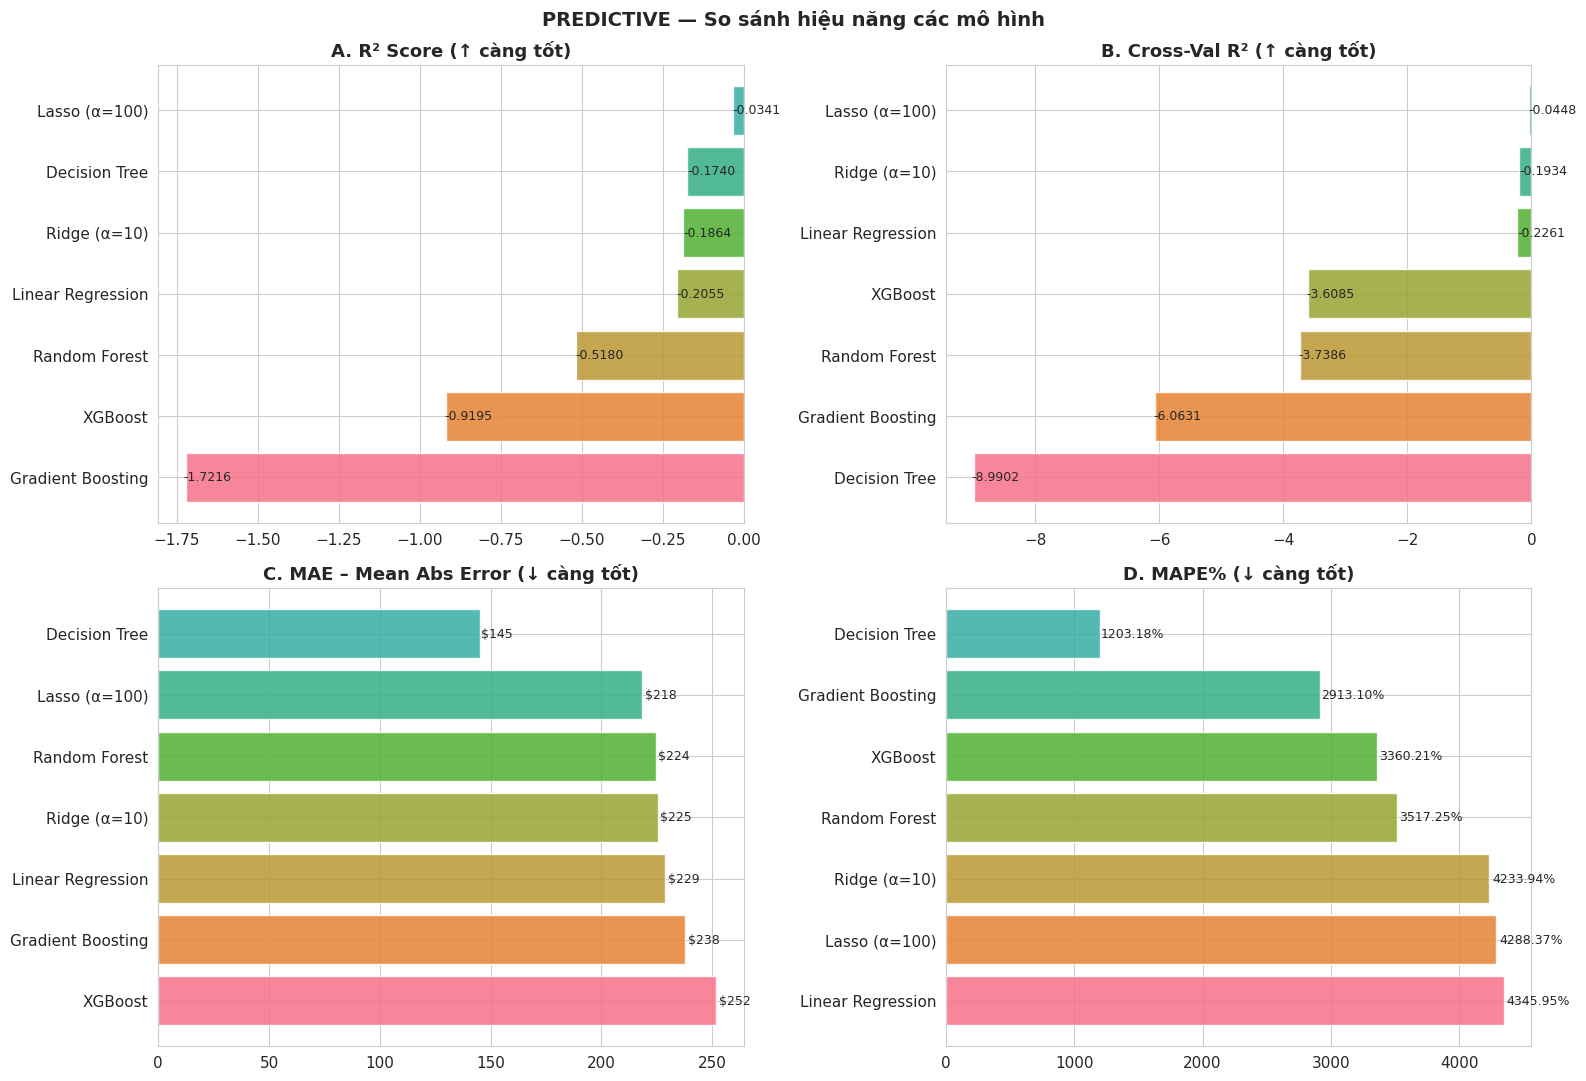

💾 Lưu: pred_01_model_comparison.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('PREDICTIVE — So sánh hiệu năng các mô hình', fontsize=14, fontweight='bold')

bar_colors = [PALETTE[i % len(PALETTE)] for i in range(len(results_df))]

def bar_chart(ax, col, title, ascending=False, fmt='%.4f'):
    data = results_df.sort_values(col, ascending=ascending)
    bars = ax.barh(data['Model'], data[col],
                   color=bar_colors, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    for bar, val in zip(bars, data[col]):
        ax.text(val * 1.005, bar.get_y() + bar.get_height()/2,
                fmt % val, va='center', fontsize=9)

bar_chart(axes[0,0], 'R²',    'A. R² Score (↑ càng tốt)',     ascending=True,  fmt='%.4f')
bar_chart(axes[0,1], 'CV-R²', 'B. Cross-Val R² (↑ càng tốt)', ascending=True,  fmt='%.4f')
bar_chart(axes[1,0], 'MAE',   'C. MAE – Mean Abs Error (↓ càng tốt)', ascending=False, fmt='$%.0f')
bar_chart(axes[1,1], 'MAPE%', 'D. MAPE% (↓ càng tốt)',        ascending=False, fmt='%.2f%%')

plt.tight_layout()
plt.savefig('pred_01_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: pred_01_model_comparison.png')

---
## 📌 PHẦN 4: PHÂN TÍCH SAI SỐ MÔ HÌNH TỐT NHẤT

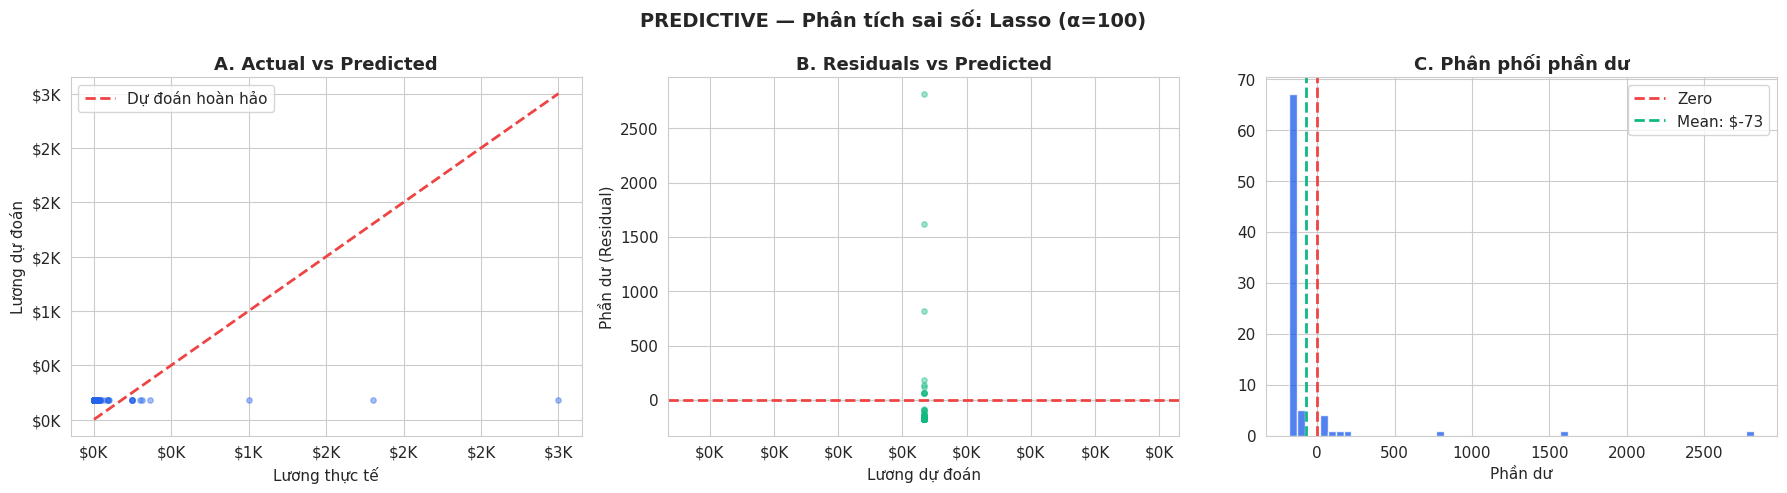

💾 Lưu: pred_02_error_analysis.png


In [7]:
y_pred_best = best['_pred']
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'PREDICTIVE — Phân tích sai số: {best["Model"]}', fontsize=14, fontweight='bold')

# [A] Actual vs Predicted
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color=BLUE, s=15)
axes[0].plot(lims, lims, '--', color=RED, lw=2, label='Dự đoán hoàn hảo')
axes[0].set_xlabel('Lương thực tế')
axes[0].set_ylabel('Lương dự đoán')
axes[0].set_title('A. Actual vs Predicted')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].legend()

# [B] Residuals vs Predicted
axes[1].scatter(y_pred_best, residuals, alpha=0.4, color=GREEN, s=15)
axes[1].axhline(0, color=RED, linestyle='--', lw=2)
axes[1].set_xlabel('Lương dự đoán')
axes[1].set_ylabel('Phần dư (Residual)')
axes[1].set_title('B. Residuals vs Predicted')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))

# [C] Residual Distribution
axes[2].hist(residuals, bins=60, color=BLUE, edgecolor='white', alpha=0.8)
axes[2].axvline(0, color=RED, linestyle='--', lw=2, label='Zero')
axes[2].axvline(np.mean(residuals), color=GREEN, linestyle='--', lw=2,
                label=f'Mean: ${np.mean(residuals):,.0f}')
axes[2].set_title('C. Phân phối phần dư')
axes[2].set_xlabel('Phần dư')
axes[2].legend()

plt.tight_layout()
plt.savefig('pred_02_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Lưu: pred_02_error_analysis.png')

---
## 📌 PHẦN 5: FEATURE IMPORTANCE — Yếu tố ảnh hưởng mạnh nhất
### ❓ Câu hỏi 4: Yếu tố nào ảnh hưởng mạnh nhất đến lương?

📊 Feature Importance — Decision Tree:
-------------------------------------------------------
  salary                       █████████████████████████ 51.10%
  location                     ███████████████████       39.41%
  job_title                    ██                        5.21%
  rating                       █                         2.40%
  employment_status                                      1.57%
  job_roles                                              0.30%
  salaries_reported                                      0.02%


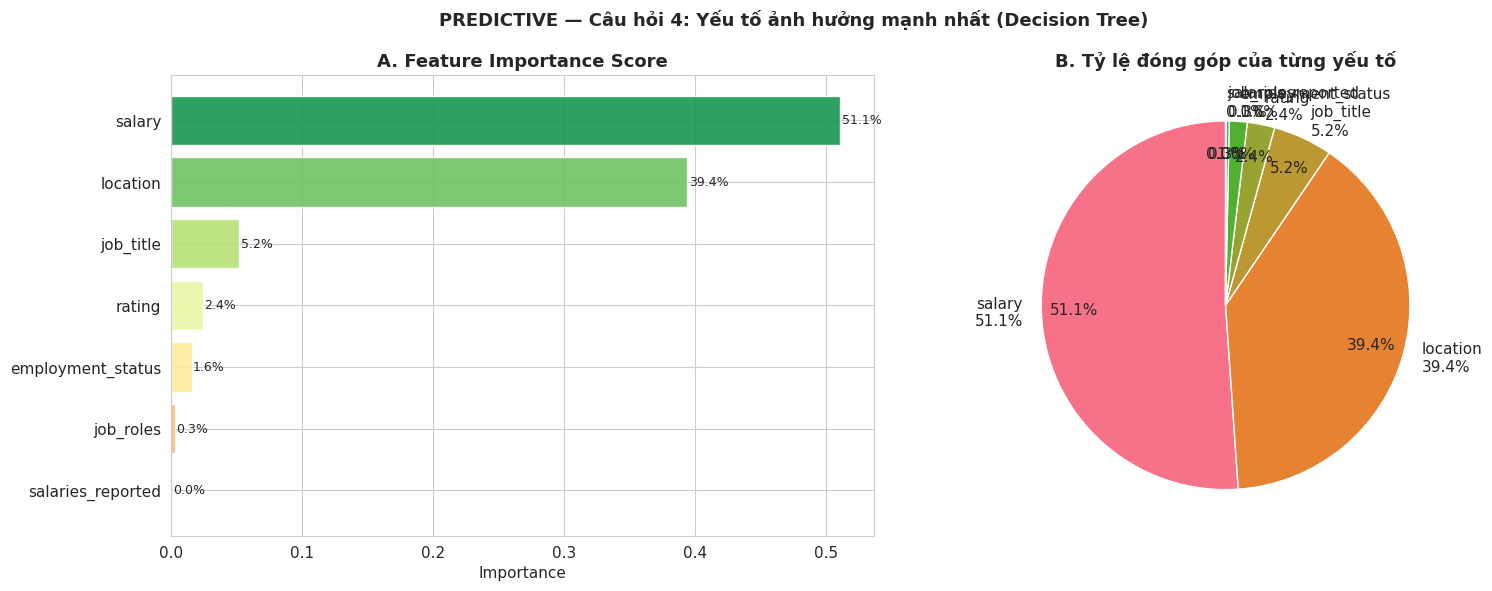

💾 Lưu: pred_03_feature_importance.png


In [8]:
# Chọn mô hình tree-based tốt nhất để lấy feature importance
tree_names  = ['XGBoost','Random Forest','Gradient Boosting','Decision Tree']
tree_result = next(
    (r for r in sorted(results, key=lambda x: -x['R²']) if r['Model'] in tree_names),
    None
)

if tree_result:
    importance = pd.DataFrame({
        'Feature'   : FEATURE_NAMES,
        'Importance': tree_result['_model'].feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    print(f'📊 Feature Importance — {tree_result["Model"]}:')
    print('-'*55)
    for _, row in importance.iterrows():
        bar = '█' * int(row['Importance'] * 50)
        print(f'  {row["Feature"]:<28} {bar:<25} {row["Importance"]*100:.2f}%')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f'PREDICTIVE — Câu hỏi 4: Yếu tố ảnh hưởng mạnh nhất ({tree_result["Model"]})',
        fontsize=13, fontweight='bold'
    )

    # Bar chart
    top_imp    = importance.sort_values('Importance')
    colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top_imp)))
    bars = axes[0].barh(top_imp['Feature'], top_imp['Importance'],
                        color=colors_imp, edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, top_imp['Importance']):
        axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val*100:.1f}%', va='center', fontsize=9)
    axes[0].set_title('A. Feature Importance Score')
    axes[0].set_xlabel('Importance')

    # Pie chart
    imp_vals = importance['Importance'].values
    imp_lbls = [f"{r['Feature']}\n{r['Importance']*100:.1f}%"
                for _, r in importance.iterrows()]
    axes[1].pie(imp_vals, labels=imp_lbls, autopct='%1.1f%%',
                colors=PALETTE[:len(imp_vals)], startangle=90, pctdistance=0.82)
    axes[1].set_title('B. Tỷ lệ đóng góp của từng yếu tố')

    plt.tight_layout()
    plt.savefig('pred_03_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Lưu: pred_03_feature_importance.png')

---
## 📌 PHẦN 6: SHAP VALUES — Giải thích mô hình chuyên sâu

⏳ Đang tính SHAP values cho: Decision Tree...


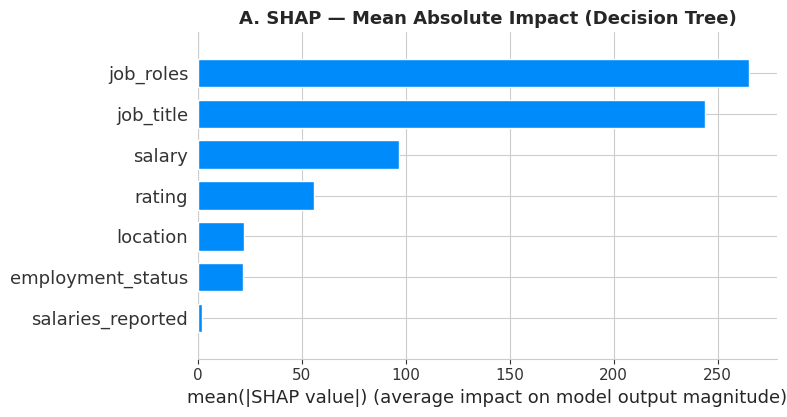

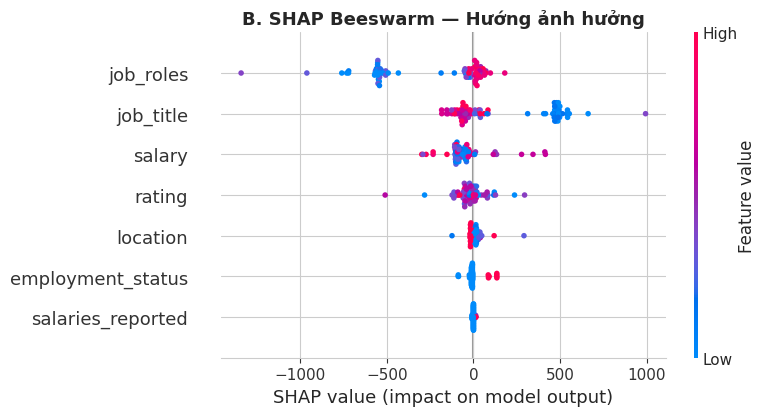


📊 SHAP Importance ranking (Decision Tree):
   1. job_roles                    ██████████████████████████████ 265.35
   2. job_title                    ███████████████████████████ 244.04
   3. salary                       ██████████ 96.66
   4. rating                       ██████ 55.92
   5. location                     ██ 22.23
   6. employment_status            ██ 21.70
   7. salaries_reported             2.00
💾 Đã lưu: pred_04a_shap_bar.png & pred_04b_shap_beeswarm.png


In [11]:
# ── PHẦN 6: SHAP VALUES ──────────────────────────────────────
tree_names = ['XGBoost', 'Random Forest', 'Gradient Boosting', 'Decision Tree']
tree_result = next(
    (r for r in sorted(results, key=lambda x: -x['R²']) if r['Model'] in tree_names),
    None
)

if tree_result is None:
    print('⚠️  Không tìm thấy tree-based model để tính SHAP.')
else:
    print(f'⏳ Đang tính SHAP values cho: {tree_result["Model"]}...')
    try:
        explainer   = shap.TreeExplainer(tree_result['_model'])
        shap_values = explainer.shap_values(X_test)

        # --- Plot 1: Bar (Mean Absolute SHAP) ---
        fig1, ax1 = plt.subplots(figsize=(9, 5))
        shap.summary_plot(shap_values, X_test,
                          feature_names=FEATURE_NAMES,
                          plot_type='bar', show=False)
        plt.title(f'A. SHAP — Mean Absolute Impact ({tree_result["Model"]})',
                  fontweight='bold')
        plt.tight_layout()
        plt.savefig('pred_04a_shap_bar.png', dpi=150, bbox_inches='tight')
        plt.show()

        # --- Plot 2: Beeswarm ---
        fig2, ax2 = plt.subplots(figsize=(9, 5))
        shap.summary_plot(shap_values, X_test,
                          feature_names=FEATURE_NAMES,
                          show=False)
        plt.title('B. SHAP Beeswarm — Hướng ảnh hưởng', fontweight='bold')
        plt.tight_layout()
        plt.savefig('pred_04b_shap_beeswarm.png', dpi=150, bbox_inches='tight')
        plt.show()

        # --- Bảng ranking ---
        shap_mean = pd.DataFrame({
            'Feature'  : FEATURE_NAMES,
            'SHAP_mean': np.abs(shap_values).mean(axis=0)
        }).sort_values('SHAP_mean', ascending=False)

        print(f'\n📊 SHAP Importance ranking ({tree_result["Model"]}):')
        for i, (_, row) in enumerate(shap_mean.iterrows(), 1):
            bar = '█' * int(row['SHAP_mean'] / shap_mean['SHAP_mean'].max() * 30)
            print(f'   {i}. {row["Feature"]:<28} {bar} {row["SHAP_mean"]:,.2f}')

        print('💾 Đã lưu: pred_04a_shap_bar.png & pred_04b_shap_beeswarm.png')

    except Exception as e:
        print(f'⚠️  SHAP lỗi: {e}')

---
## ✅ KẾT LUẬN TẦNG 3 — PREDICTIVE

### Mô hình tốt nhất:
| Chỉ số | Giá trị |
|--------|--------|
| Mô hình | *(điền sau khi chạy)* |
| R² Score | *(điền sau khi chạy)* |
| MAE | *(điền sau khi chạy)* |
| MAPE | *(điền sau khi chạy)* |

### Câu hỏi 4 — Yếu tố ảnh hưởng mạnh nhất:
1. **#1:** **
2. **#2:** **
3. **#3:** **

➡️ **Tiếp theo: `04_prescriptive.ipynb`**